# tiny-yolov3-voc sur voc — balayage lot × sous-ensemble

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lrivals/EmbeddedComputervision/blob/main/notebooks/voc/tiny-yolov3-voc_sweep.ipynb)

Rôle : balayage lot × sous-ensemble ; palier **N** (6 runs de 600 itérations par défaut) ; chaque run est évalué sur `SUBSET` images, puis comparé aux autres. Tâches : [T2.9](../../docs/tasks/M2-cibles-perte-entrainement.md), [T9.2](../../docs/tasks/M9-extensions.md), [T9.3](../../docs/tasks/M9-extensions.md), [T14.10](../../docs/tasks/M14-notebooks.md) ;
notebooks : [M14](../../docs/tasks/M14-notebooks.md).

Prérequis :
- données : `data/VOCdevkit/VOC2007/ImageSets/Main/test.txt` — tools/get_voc.sh
- poids : `weights/yolov3-tiny.weights` — tools/get_weights.sh

Chaque étape affiche la commande `python tools/…` qu'elle lance : un résultat se
reproduit en ligne de commande. Sorties dans `build/notebooks/voc/tiny-yolov3-voc/`, jamais dans `results/`
(une mAP sur `SUBSET` images n'est pas publiable, règles de M12). Notebook généré par
`python -m tools.notebooks` (`make notebooks`) : modifier le gabarit
`tools/notebooks/gabarits.py`, pas ce fichier.

## Paramètres

In [8]:
NET           = 'tiny-yolov3-voc'  # nom de CFG_FILES ou cfg (relative à la racine)
DATASET       = 'voc'  # clé de DATASETS
SPLIT         = None  # None : split d'évaluation du jeu
WEIGHTS       = None  # par run : OUT/runs/<run>/final.weights
DEVICE        = 'gpu'  # cpu | gpu (entraînement seulement ; le reste sur CPU)
SUBSET        = 50  # images évaluées ; 0 : split complet (palier N)
SIZE          = None  # entrée LxH (ex. '640x192') ; None : celle de la cfg
RESIZE        = 'stretch'  # stretch (référence M12) | letterbox
METRIC        = None  # None : celle du jeu (coco pour coco et flir)
DATA_ROOT     = None  # racine du jeu ; None : data/<jeu> (Colab : dossier Drive)
BASE          = 'tiny-yolov3-voc'  # base de make_cfg.py
CHANNELS      = None  # canaux de la cfg (1 : thermique)
ANCHORS_K     = 6  # ancres de la cfg (6 : Tiny-YOLOv3)
INIT          = 'coco'  # coco | he | chemin d'un .weights
INIT_NET      = None  # réseau des poids de INIT s'il diffère de NET
BATCHES       = [8, 16, 32]  # tailles de lot essayées
TRAIN_SUBSETS = [500, 0]  # images d'entraînement (n premières) ; 0 : tout le split
ITERS         = 600  # itérations par run (palier N dès 600)
SKIP_DONE     = True  # saute les runs qui ont déjà final.weights
LR            = 0.001
BURN_IN       = 500
MULTISCALE    = True  # 320-608 tous les 10 lots
SAVE_EVERY    = None  # None : défaut de train.py (200)
WORKERS       = 4
DRIVE_DIR     = '/content/drive/MyDrive/EmbeddedCV'  # Colab : archives data/<jeu>.tar, sorties et reprise dans runs/ ; None : pas de Drive
JOBS          = 4  # processus des évaluations
SHOW          = 6  # images affichées
OUT           = 'build/notebooks/voc/tiny-yolov3-voc'  # sorties du notebook
REPO_URL      = 'https://github.com/lrivals/EmbeddedComputervision.git'  # Colab : dépôt cloné
REV           = 'main'  # Colab : révision

## Environnement

Local : rien n'est installé ni téléchargé, la cellule vérifie les prérequis et
s'arrête avec la commande à lancer. Colab : clone du dépôt, installation, CuPy si
`DEVICE = "gpu"`, poids, puis données par `colab.prepare_data` (archive
`<DRIVE_DIR>/data/<jeu>.tar` ou téléchargement direct ; ExDark et FLIR : archive
seulement, faite sur le PC par `tools/get_datasets.sh pack <jeu>`).

In [9]:
import os
import subprocess
import sys
from pathlib import Path

COLAB = "google.colab" in sys.modules


def repo_root():
    for d in (Path.cwd(), *Path.cwd().parents):
        if (d / "tools" / "notebooks" / "commandes.py").exists():
            return d
    return None


ROOT = repo_root()
if COLAB:
    if ROOT is None:
        ROOT = Path("/content/EmbeddedComputervision")
        if not ROOT.exists():
            subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
    # Clone d'une session précédente : remis à REV (notebook et code du même commit).
    subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin", REV], check=True)
    subprocess.run(["git", "-C", str(ROOT), "checkout", "-q", "FETCH_HEAD"], check=True)
    for m in [m for m in sys.modules if m.split(".")[0] in ("tools", "yolo")]:
        del sys.modules[m]  # modules importés avant la mise à jour
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    f"{ROOT}/python[data,plots]"], check=True)
    if DEVICE == "gpu":
        # Runtime CPU : pas de pilote, CuPy dirait « cudaErrorInsufficientDriver ».
        try:
            smi = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
        except FileNotFoundError:
            smi = None
        if smi is None or smi.returncode != 0:
            raise RuntimeError("runtime Colab sans GPU : créer un nouveau serveur Colab "
                               "de type GPU (T4, L4 ou A100), ou DEVICE = 'cpu'")
        cuda = smi.stdout.split("CUDA Version:")[-1].split()[0]  # version du pilote
        cupy_pkg = "cupy-cuda13x" if int(cuda.split(".")[0]) >= 13 else "cupy-cuda12x"
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", cupy_pkg],
                       check=True)
elif ROOT is None:
    raise RuntimeError("racine du dépôt introuvable : ouvrir le notebook depuis notebooks/")
os.chdir(ROOT)
for p in (ROOT, ROOT / "python"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from tools.notebooks import commandes as C
from tools.notebooks import env

TRACE = env.trace(DEVICE)
env.check_device(DEVICE)
env.prepare(DATASET, INIT if str(INIT).endswith('.weights') else 'weights/yolov3-tiny.weights' if INIT == 'coco' else (), None, DATA_ROOT, COLAB, hint='',
            drive_dir=DRIVE_DIR)
Path(OUT).mkdir(parents=True, exist_ok=True)

dépôt /content/EmbeddedComputervision @ 1a967f4 ; Python 3.13.15 ; NumPy 2.1.3 ; backend gpu
GPU : 1 visible(s), CuPy 14.0.1
données voc : data/VOCdevkit/VOC2007/ImageSets/Main/test.txt ; poids : weights/yolov3-tiny.weights


## Préparation (jeux hors VOC)

Ancres k-means sur le split d'entraînement (`tools/kmeans_anchors.py`, table dans
`OUT`), puis cfg à N classes (`tools/make_cfg.py`), comme `tools/m11.sh <jeu>-prep`.
Sautée si la cfg existe déjà.

In [10]:
import csv
import json

import numpy as np
from IPython.display import Markdown, display
from PIL import Image

from tools.detect import draw
from tools.notebooks.matrice import estimate
from yolo.data import datasets
from yolo.data.letterbox import input_size, parse_size, size_label
from yolo.models.tiny_yolo import load_cfg

if not str(NET).endswith(".cfg"):
    print(f"{NET} : cfg du dépôt, pas de préparation")
elif Path(NET).exists():
    print(f"{NET} existe : préparation sautée")
else:
    anchors = Path(OUT) / f"anchors_{DATASET}{'_' + str(SIZE) if SIZE else ''}.md"
    C.run(C.cmd_anchors(DATASET, SIZE, anchors, DATA_ROOT))
    C.run(C.cmd_make_cfg(BASE, DATASET, C.anchors_k(anchors, ANCHORS_K), NET, SIZE,
                         CHANNELS))

tiny-yolov3-voc : cfg du dépôt, pas de préparation


## Aperçu des cibles

Quelques images augmentées (`yolo.data.loader.VOCDataset`, donc `yolo.data.augment`)
avec leurs boîtes : contrôle des annotations avant des heures de calcul.

16551 images d'entraînement, entrée 416×416, 3 canal(aux)


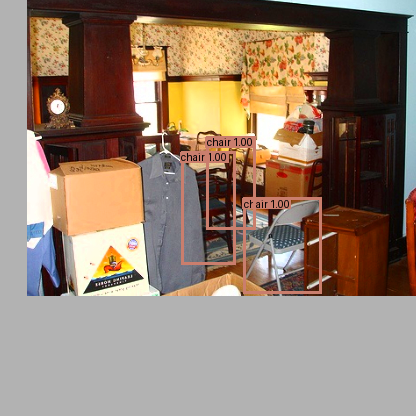

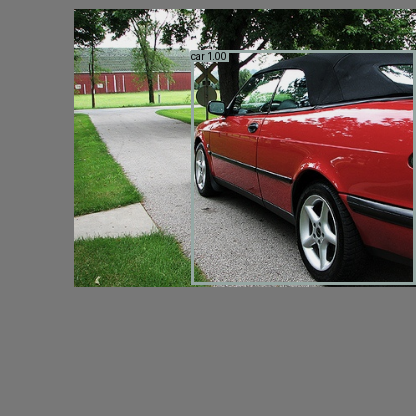

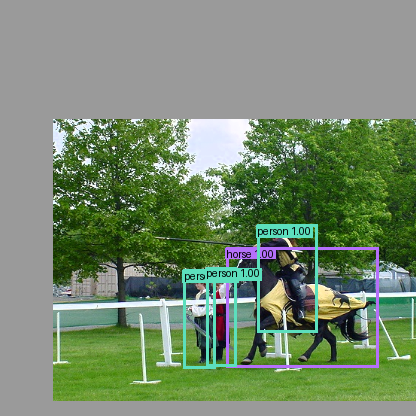

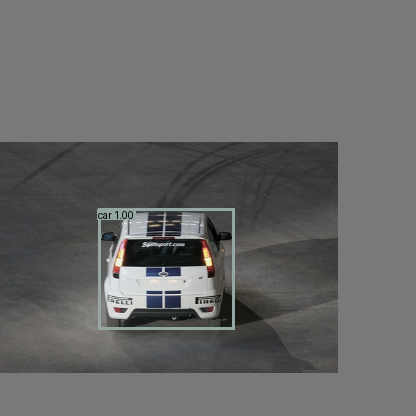

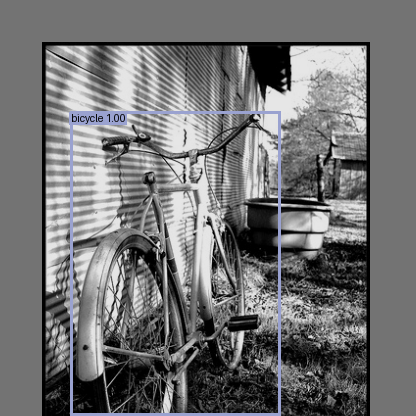

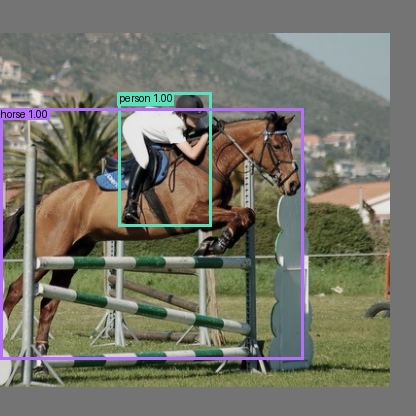

In [11]:
cfg = load_cfg(NET)
size = input_size(cfg, parse_size(SIZE) if SIZE else None)
channels = cfg["input"][0]
names = datasets.DATASETS[DATASET].classes
samples = datasets.load(DATASET, DATA_ROOT, role="train")
print(f"{len(samples)} images d'entraînement, entrée {size_label(size)}, {channels} canal(aux)")
from yolo.data.loader import VOCDataset

preview = VOCDataset(samples[:SHOW], train=True, channels=channels)
for k in range(len(preview)):
    chw, boxes, labels = preview.load(k, size, np.random.default_rng(k))
    hwc = (np.clip(chw.transpose(1, 2, 0), 0, 1) * 255).astype(np.uint8)
    img = Image.fromarray(hwc[..., 0] if channels == 1 else hwc)
    display(draw(img, boxes, np.ones(len(labels)), labels, names))

## Plan du balayage (T14.10)

Un run par case de la grille `BATCHES × TRAIN_SUBSETS`, tous les autres paramètres
égaux (ceux de `tools/m11.sh <jeu>-train`, `ITERS` à part). `TRAIN_SUBSETS` prend les
n premières images du split d'entraînement (`train.py --subset`), 0 tout le split.
À itérations égales, un lot plus grand voit plus d'images : la colonne « époques »
le montre. Le taux d'apprentissage n'est pas ajusté au lot.

In [12]:
import threading

from tools.notebooks import colab, runs

PLAN = [(b, s, runs.run_name(b, s)) for b in BATCHES for s in TRAIN_SUBSETS]
rows = ["| run | lot | images | époques | durée estimée |", "|---|---|---|---|---|"]
total = 0
for b, s, name in PLAN:
    n = min(s, len(samples)) if s else len(samples)
    sec = estimate(ITERS, b, DEVICE)
    total += sec or 0
    done = (Path(OUT) / "runs" / name / "final.weights").exists()
    rows.append(f"| {name}{' (fait)' if done else ''} | {b} | {n} | "
                f"{ITERS * b / n:.2f} | "
                + (f"{sec / 3600:.1f} h |" if sec else "non mesurée |"))
display(Markdown("\n".join(rows)))
print(f"{len(PLAN)} runs de {ITERS} itérations"
      + (f", ≈ {total / 3600:.1f} h sur {DEVICE} au total" if total else ""))

| run | lot | images | époques | durée estimée |
|---|---|---|---|---|
| b8-s500 | 8 | 500 | 9.60 | non mesurée |
| b8-sall | 8 | 16551 | 0.29 | non mesurée |
| b16-s500 | 16 | 500 | 19.20 | non mesurée |
| b16-sall | 16 | 16551 | 0.58 | non mesurée |
| b32-s500 | 32 | 500 | 38.40 | non mesurée |
| b32-sall | 32 | 16551 | 1.16 | non mesurée |

6 runs de 600 itérations


## Entraînements

Chaque run va dans `OUT/runs/<run>/` (`b16-sall`, `b8-s500`…), avec son `run.json`.
Relancer la cellule reprend le run interrompu (`--resume`) et saute ceux qui sont
finis (`SKIP_DONE`). Sur Colab avec `DRIVE_DIR`, `OUT` est copié dans
`<DRIVE_DIR>/runs/` toutes les 10 min et en fin de cellule (T14.8).

In [13]:
SYNC = COLAB and bool(DRIVE_DIR)
if SYNC:
    env.mount_drive(DRIVE_DIR)
    colab.restore_outputs(OUT, DRIVE_DIR)
stop = threading.Event()


def sync_loop(every=600):
    while not stop.wait(every):
        colab.sync_outputs(OUT, DRIVE_DIR)


if SYNC:
    threading.Thread(target=sync_loop, daemon=True).start()
try:
    for b, s, name in PLAN:
        run_dir = Path(OUT) / "runs" / name
        if SKIP_DONE and (run_dir / "final.weights").exists():
            print(f"{name} : déjà entraîné, sauté")
            continue
        resume = (run_dir / "checkpoint.npz").exists()
        runs.write_meta(run_dir, batch=b, subset=s, iters=ITERS, lr=LR, device=DEVICE,
                        net=NET, dataset=DATASET, rev=TRACE["rev"])
        C.run(C.cmd_train(NET, run_dir, DATASET, INIT, INIT_NET, resume, iters=ITERS,
                          batch=b, lr=LR, burn_in=BURN_IN, multiscale=MULTISCALE,
                          subset=s, save_every=SAVE_EVERY, workers=WORKERS,
                          device=DEVICE, data_root=DATA_ROOT),
              log=run_dir / "log.txt")
finally:
    stop.set()
    if SYNC:
        colab.sync_outputs(OUT, DRIVE_DIR)

/content/drive/MyDrive/EmbeddedCV/runs/build/notebooks/voc/tiny-yolov3-voc → build/notebooks/voc/tiny-yolov3-voc
$ python tools/train.py --net tiny-yolov3-voc --init coco --iters 600 --batch 8 --lr 0.001 --burn-in 500 --multiscale --subset 500 --workers 4 --device gpu --out build/notebooks/voc/tiny-yolov3-voc/runs/b8-s500
poids yolov3-tiny.weights copiés ; couches réinitialisées : [15, 22]
backend : gpu
500 images, 62 lots par époque
it      1  lr 1.60e-14  perte 5052.972  coord 15.952 obj 2.277 noobj 5004.746 cls 29.996
it      2  lr 2.56e-13  perte 5027.933  coord 31.320 obj 2.386 noobj 4946.106 cls 48.121
it      3  lr 1.30e-12  perte 5059.553  coord 16.710 obj 3.321 noobj 4985.441 cls 54.082
it      4  lr 4.10e-12  perte 5002.747  coord 8.011 obj 1.278 noobj 4968.016 cls 25.441
it      5  lr 1.00e-11  perte 4954.210  coord 15.224 obj 1.992 noobj 4902.077 cls 34.917
it      6  lr 2.07e-11  perte 5084.676  coord 19.142 obj 1.873 noobj 5025.879 cls 37.782
it      7  lr 3.84e-11  perte

## Comparaison

mAP flottante de chaque run sur les mêmes `SUBSET` images (`tools/eval_voc.py`,
réutilisée si déjà calculée), perte finale et vitesse ; courbes de perte superposées
(`tools.figures.resultats.plot_training`, M13). Les notebooks d'inférence
`<modèle>_infer` lisent ces runs (`RUN`, `COMPARE`).

$ python tools/eval_voc.py --net tiny-yolov3-voc --weights build/notebooks/voc/tiny-yolov3-voc/runs/b16-s500/final.weights --dataset voc --resize stretch --subset 50 --out build/notebooks/voc/tiny-yolov3-voc/runs/b16-s500/dets_s50 --markdown build/notebooks/voc/tiny-yolov3-voc/runs/b16-s500/map_float_s50.md
50/50 images      14 s  (282 ms/image)
détections : build/notebooks/voc/tiny-yolov3-voc/runs/b16-s500/dets_s50
### tiny-yolov3-voc (final.weights), VOC2007 test, 50 images, 416×416 stretch (pil), conf 0.005, NMS 0.45, AP 11 points

| Classe | AP |
|---|---|
| aeroplane | 100.0 |
| bicycle | 50.0 |
| bird | 8.6 |
| boat | 0.7 |
| bottle | 0.0 |
| bus | 1.4 |
| car | 24.8 |
| cat | 60.9 |
| chair | 28.1 |
| cow | 0.6 |
| diningtable | 57.1 |
| dog | 40.0 |
| horse | 57.3 |
| motorbike | 18.2 |
| person | 22.2 |
| pottedplant | 0.0 |
| sheep | 25.0 |
| sofa | 0.0 |
| train | 4.6 |
| tvmonitor | 12.1 |
| **mAP** | **25.58** |

figures : build/notebooks/voc/tiny-yolov3-voc/runs/b16-s500/

| run | lot | images | itérations | backend | perte finale | mAP | s/image | éval. |
|---|---|---|---|---|---|---|---|---|
| b32-sall | 32 | tout | 600 | gpu | 14.66 | 36.27 | 0.04 | 50 |
| b16-sall | 16 | tout | 600 | gpu | 17.45 | 34.70 | 0.04 | 50 |
| b8-s500 | 8 | 500 | 600 | gpu | 18.00 | 30.14 | 0.04 | 50 |
| b16-s500 | 16 | 500 | 600 | gpu | 13.78 | 25.58 | 0.04 | 50 |
| b32-s500 | 32 | 500 | 600 | gpu | 11.95 | 24.01 | 0.04 | 50 |
| b8-sall | 8 | tout | 600 | gpu | 18.29 | 12.41 | 0.04 | 50 |

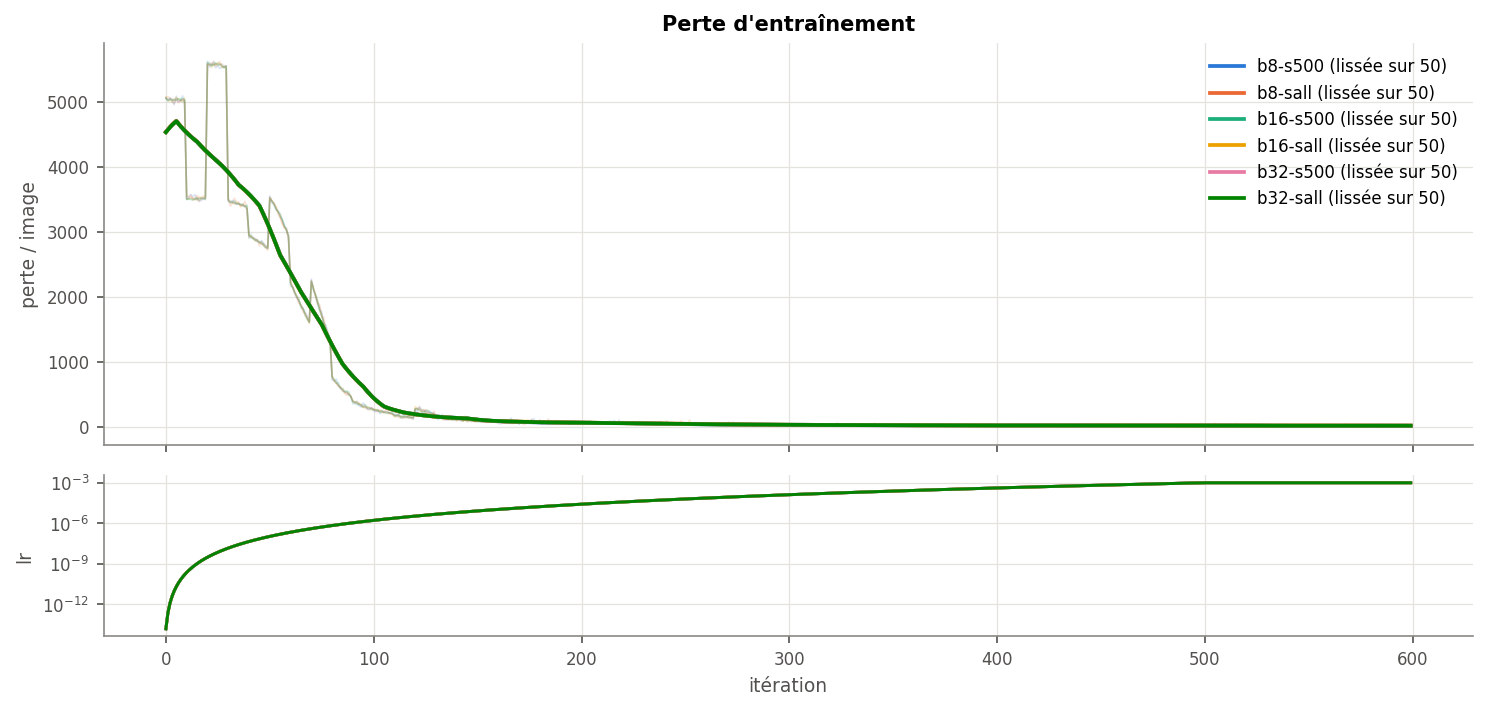

In [14]:
from tools.figures import MissingSource
from tools.figures import resultats as FR

RESULTS = [runs.evaluate(r, NET, DATASET, RESIZE, SUBSET, METRIC, SPLIT, SIZE, DATA_ROOT)
           for r in runs.find_runs(OUT) if r.name != runs.TRAIN]
display(Markdown(runs.table(RESULTS)))
curves = []
for b, s, name in PLAN:
    try:
        curves.append(FR.load_training(Path(OUT) / "runs" / name))
    except MissingSource:
        pass
if curves:
    for png in FR.plot_training(curves, Path(OUT) / "figures", "balayage"):
        if str(png).endswith(".png"):
            display(Image.open(png))

## Résumé

In [15]:
print(f"runs : {OUT}/runs/ ; backend {DEVICE} ; révision {TRACE['rev']}")
best = max((r for r in RESULTS if r["mAP"] is not None), key=lambda r: r["mAP"],
           default=None)
if best:
    print(f"meilleur run sur {SUBSET or 'toutes les'} images : {best['run']} "
          f"(mAP {best['mAP']:.2f}) ; inférence : RUN = {best['run']!r}")
print("commandes équivalentes :")
for c in C.HISTORY:
    print("  " + c)

runs : build/notebooks/voc/tiny-yolov3-voc/runs/ ; backend gpu ; révision 1a967f4
meilleur run sur 50 images : b32-sall (mAP 36.27) ; inférence : RUN = 'b32-sall'
commandes équivalentes :
  python tools/train.py --net tiny-yolov3-voc --init coco --iters 600 --batch 8 --lr 0.001 --burn-in 500 --multiscale --subset 500 --workers 4 --device gpu --out build/notebooks/voc/tiny-yolov3-voc/runs/b8-s500
  python tools/train.py --net tiny-yolov3-voc --init coco --iters 600 --batch 8 --lr 0.001 --burn-in 500 --multiscale --workers 4 --device gpu --out build/notebooks/voc/tiny-yolov3-voc/runs/b8-sall
  python tools/train.py --net tiny-yolov3-voc --init coco --iters 600 --batch 16 --lr 0.001 --burn-in 500 --multiscale --subset 500 --workers 4 --device gpu --out build/notebooks/voc/tiny-yolov3-voc/runs/b16-s500
  python tools/train.py --net tiny-yolov3-voc --init coco --iters 600 --batch 16 --lr 0.001 --burn-in 500 --multiscale --workers 4 --device gpu --out build/notebooks/voc/tiny-yolov3-voc/runs